In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, re
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd
import scanpy as sc

import time
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch


# main_dir = "/home/wz369/rds/hpc-work/PINN_dynamics"
main_dir = "/Users/weizhongzheng/Documents/python_project/PINN_dynamics/"
os.chdir(main_dir)

In [143]:
sc.settings.set_figure_params(frameon=False, dpi=100, figsize=(4,4))

# load data

In [3]:
# # load dataset

adata = sc.read_h5ad(f'data/ery_mk_Aug1.h5ad')
# tompos = sc.read_h5ad(f'data/tom_pos.h5ad')

In [31]:
# set up groups for comparision
adata.obs['stage'] = adata.obs['timepoint_tx_days'].astype(str).map(
    {'3':'early', '7':'early','12':'early', '27':'intermediate', '49':'late', '76':'late'}
)


In [140]:

# use the raw to get all genes
raw_ad = adata.raw.to_adata()

# only look at MEP
# & `data_type` == '10x'
selection = adata.obs.query("`anno_man` == 'Int prog' & `timepoint_tx_days` <= 49 ").index
MEP_ad = raw_ad[selection].copy()

MEP_ad


AnnData object with n_obs × n_vars = 946 × 22035
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'lo

In [33]:
MEP_ad.obs['stage'].value_counts()

stage
intermediate    411
late            326
early            80
Name: count, dtype: int64

In [65]:
transcription_factors = ['Gata1', 'Gata2', 'Tal1', 'Lmo2', 'Klf1', 'Fli1', 'Erg', 'Spi1']
regulators_cofactors   = ['Zfpm1', 'Gfi1b', 'Runx1', 'Sox6', 'Myb']
signaling              = ['Epor', 'Jak2', 'Stat5a', 'Stat5b', 'Kit']
chromatin_epigenetic   = ['Hira', 'Setd8', 'Bach1', 'Bach2']
other_regulators       = ['Nfe2', 'Myc', 'Ccna2', 'Bcl2l1']
novel_factors          = ['Vac14', 'Akap8l', 'Terf2ip', 'Rnf10', 'Edag', 'Hmg20b']

# T-test

In [44]:
sc.tl.rank_genes_groups(MEP_ad, 'stage',  groups= ['late'], reference='early',
                         method='t-test', key_added = "t-test")
deg_ttest = sc.get.rank_genes_groups_df(MEP_ad, group = ['late'], key = "t-test")
deg_ttest.head()

,names,scores,logfoldchanges,pvals,pvals_adj
0,Elane,11.578315,4.028766,5.738702e-27,4.215077e-23
1,Mpo,8.704964,2.271034,1.512918e-16,6.667429e-13
2,Il11ra1,8.557385,4.031167,2.683073e-16,9.853587e-13
3,Rps18,8.541612,0.311656,3.000052e-14,6.610615e-11
4,Ctsg,7.967557,3.167953,1.763101e-14,4.459459e-11


In [183]:
deg_ttest.query('`pvals_adj` < 0.05').to_csv("MEPs_DEG.csv")

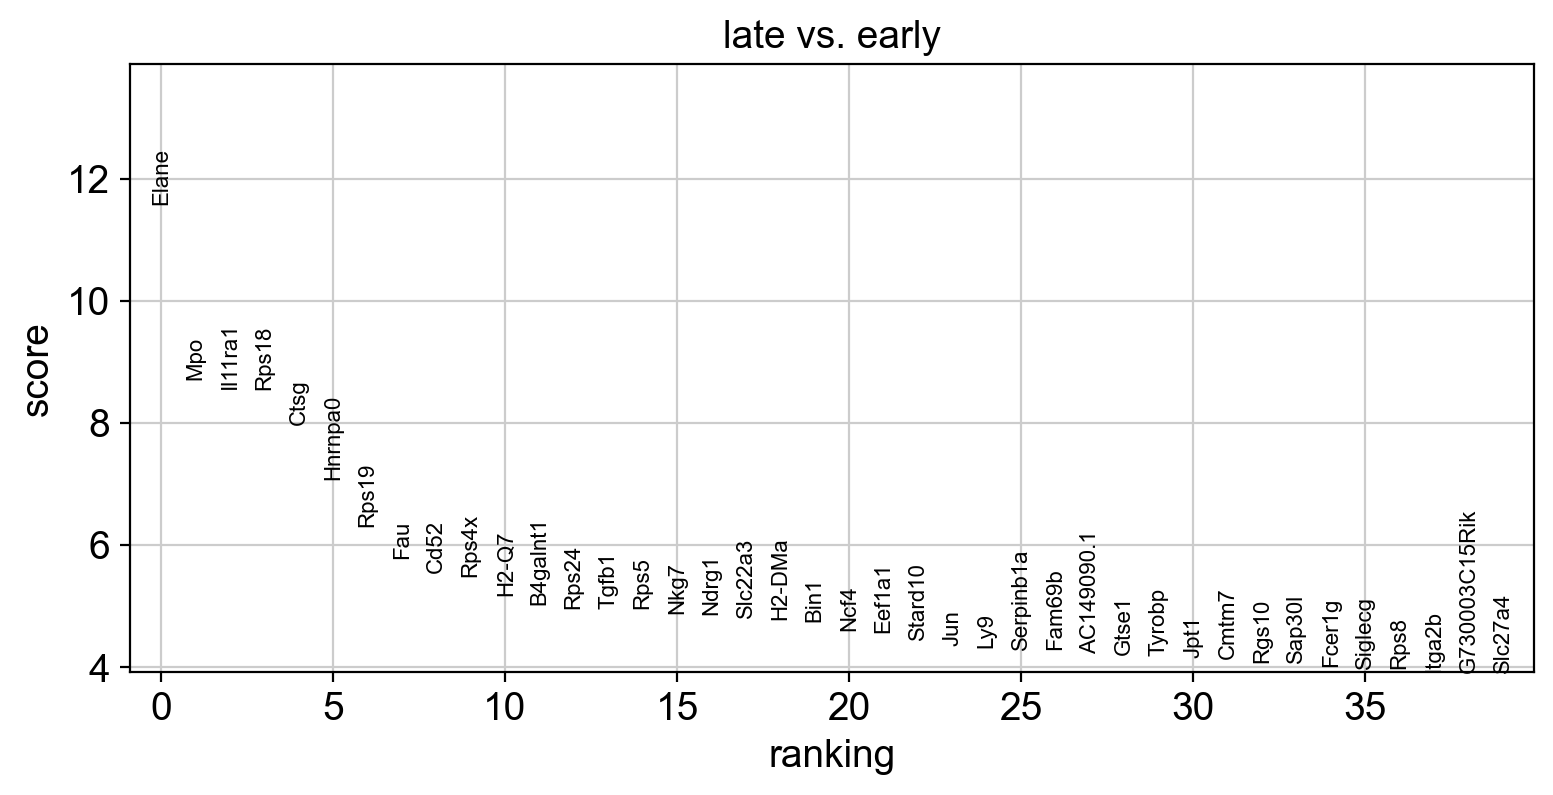

In [24]:
fig = plt.figure(figsize=(9,4))
ax = fig.gca()
ax.axis("off")
g = sc.pl.rank_genes_groups(MEP_ad, n_genes=40, sharey=False, key = "t-test", ax=ax, show=False)


# wilcoxon

In [43]:
sc.tl.rank_genes_groups(MEP_ad, 'stage', groups= ['late'], reference='early', method='wilcoxon', key_added = "wilcoxon")
deg_wilco = sc.get.rank_genes_groups_df(MEP_ad, group = ['late'], key = "wilcoxon")
deg_wilco.head()

,names,scores,logfoldchanges,pvals,pvals_adj
0,Rps18,7.858557,0.311656,3.885828e-15,2.140605e-11
1,Hnrnpa0,7.486416,0.769530,7.077969e-14,3.119261e-10
2,Rps19,5.804338,0.229524,6.462068e-09,1.095320e-05
3,Rps4x,5.476854,0.208247,4.329538e-08,6.360092e-05
4,Elane,5.377971,4.028766,7.532998e-08,9.764094e-05


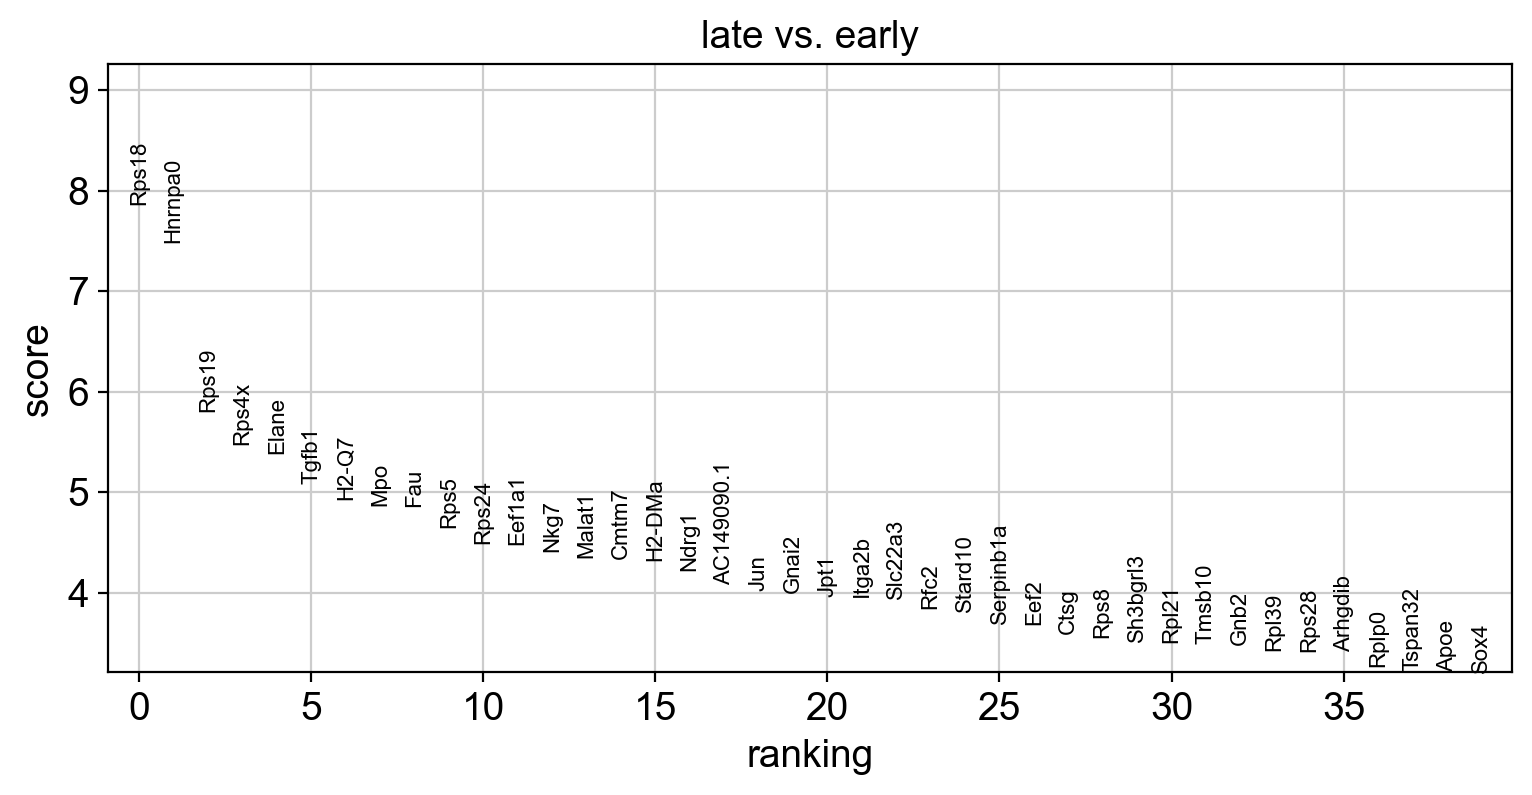

In [26]:
fig = plt.figure(figsize=(9,4))
ax = fig.gca()
ax.axis("off")
g = sc.pl.rank_genes_groups(MEP_ad, n_genes=40, sharey=False, key = "wilcoxon", ax=ax, show=False)


In [74]:
degs = []
for gs in [transcription_factors ,regulators_cofactors ,
           signaling ,chromatin_epigenetic,
           other_regulators,
           novel_factors]:
    degs.append(deg_ttest.query("`names` in @gs"))

MEP_ery_diff = pd.concat(degs)

In [ ]:
MEP_ery_diff.query("`pvals_adj`<0.05")

,names,scores,logfoldchanges,pvals,pvals_adj
70,Spi1,3.290589,0.716218,0.001243,0.129168
149,Klf1,2.792560,0.848210,0.005768,0.287048
406,Gata1,2.183982,0.447083,0.030455,0.568071
21409,Lmo2,-2.311361,-0.204287,0.022310,0.506802
21515,Tal1,-2.465678,-0.449459,0.015043,0.426271
206,Zfpm1,2.590837,0.256922,0.010428,0.360157
21283,Runx1,-2.205233,-0.336381,0.029197,0.560539
21436,Gfi1b,-2.351657,-0.565340,0.020386,0.484584
21086,Jak2,-2.026796,-0.560908,0.044845,0.680229


In [48]:
ERY_geneset = pd.read_csv("data/mouse_geneset/RIZ_ERYTHROID_DIFFERENTIATION_6HR.v2025.1.Hs.tsv", sep='\t', index_col=0)

In [55]:
ery_genes = ERY_geneset.loc['GENE_SYMBOLS'].values[0].split(",")
ery_genes = [gene.lower().capitalize() for gene in ery_genes if gene != '']
ery_genes = [g for g in ery_genes if g in adata.var_names]

In [103]:
sc.tl.score_genes(MEP_ad, ery_genes, score_name='erythrocyte_score')

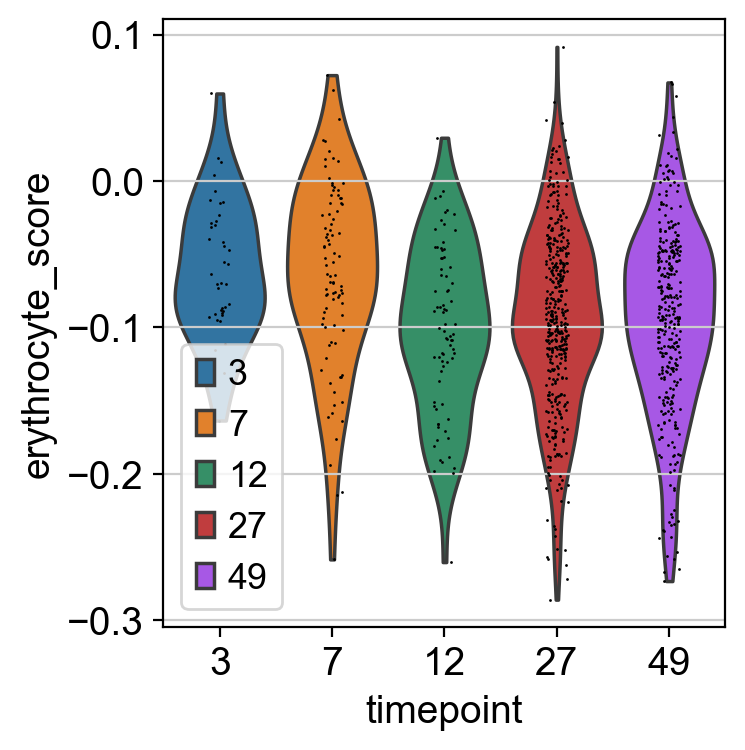

In [144]:
sc.tl.score_genes(MEP_ad, ery_genes, score_name='erythrocyte_score')
sc.pl.violin(MEP_ad, keys='erythrocyte_score', groupby='timepoint')

## genesets

In [149]:
geneset_df = pd.read_csv("data/mouse_geneset/Rodriguez-Fraticelli_HSC_gene_signatures.csv", skiprows=1)
geneset_df.head()

,Low-output_Rodriguez_et_al,High-output_Rodriguez_et_al,Multilineage_Rodriguez_et_al,Mk-bias_Rodriguez_et_al,Serial-engraftment_Rodriguez_et_al,Stemscore_Giladi_et_al,RACFP_DIM_Lauridsen_et_al,SuMO_Wilson_et_al,MolO_Wilson_et_al,HSC_vs_MPP4_Cabezas-Wallscheid_et_al,...,HSC4 cluster,dHSC_aHSC_single-cell_Cabezas-Wallscheid_et_al,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,Mpl,Plac8,Plac8,Ifitm3,Ifitm1,1110017F19Rik,Ltb,Ly6a,Procr,Prss41,...,Jun,ENSMUSG00000064339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ifitm3,H2afy,H2afy,Rbms3,Tsc22d1,2410006H16Rik;Snord65,Lst1,Ifitm1,Pdzk1ip1,Sh3gl3,...,Egr1,ENSMUSG00000098178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ifitm1,Cdk6,Mpo,Ifitm1,Mycn,2900062L11Rik;6530401D17Rik,Ypel3,Inhba,Ltb,Ncam2,...,Ier2,CYTB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Tgm2,Cd34,Elane,Adgrg1,Vwf,4931406C07Rik,Ly6a,Mllt3,Mllt3,Sh3rf3,...,Plac8,Serpinb1a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,H2-K1,Nkg7,Ybx1,Tsc22d1,Glul,AK046388,Ctsf,Wfdc2,Ifitm1,Ak7,...,Ptma,Actb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [151]:
def get_gs(column):

    geneset = geneset_df[column]

    geneset = geneset[~geneset.isna()]
    geneset = [g for g in geneset if g in MEP_ad.var_names]

    return geneset

In [153]:
multilineage_gs = get_gs('Multilineage_Rodriguez_et_al')
lowoutput_gs = get_gs('Low-output_Rodriguez_et_al')

In [158]:
import seaborn as sns
sns.set_theme(style='ticks', palette='Set2')

In [165]:
axes

In [171]:
selection = adata.obs.query("`anno_man` == 'Int prog'").index
MEP_ad = raw_ad[selection].copy()

sc.tl.score_genes(MEP_ad, multilineage_gs, score_name='multi-lineage score')
sc.tl.score_genes(MEP_ad, lowoutput_gs, score_name='low output score')


In [174]:
result_dir = 'results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2'

In [179]:
sns.set_theme(style='ticks', palette='Set2', font_scale=1.2)

/Users/weizhongzheng/mamba/envs/PINN_clean/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


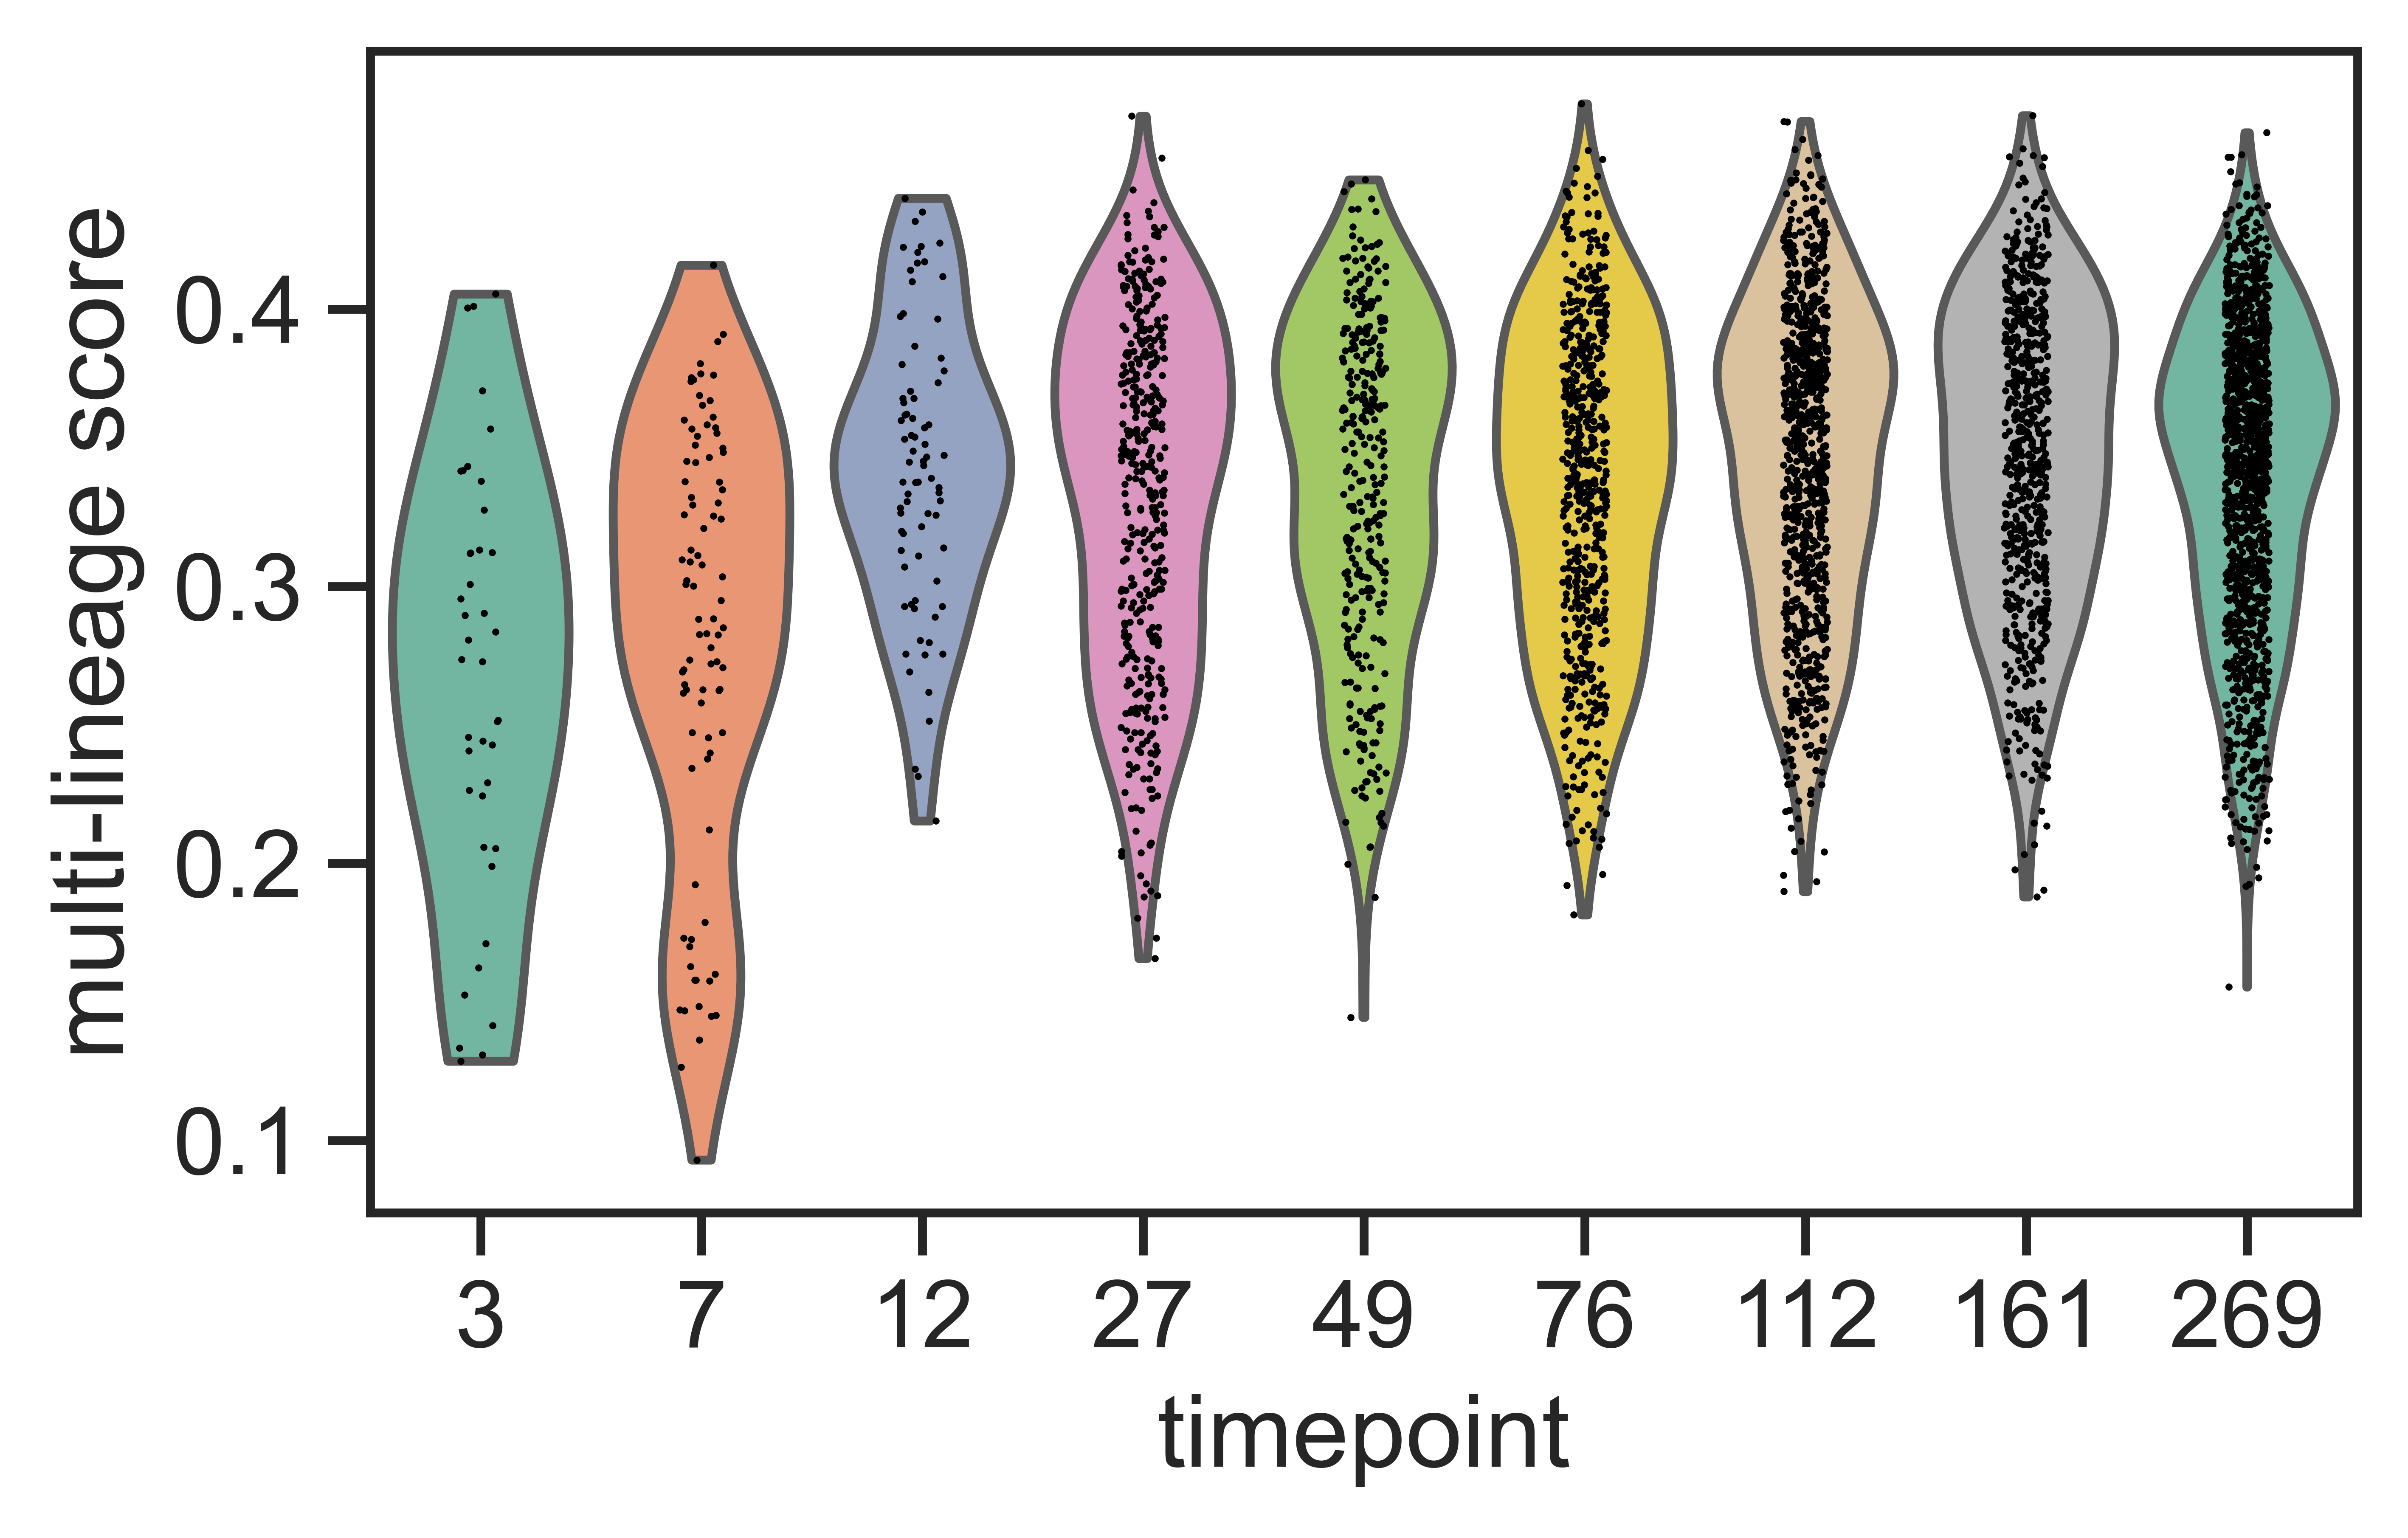

In [180]:
fig = plt.figure(figsize=(5,3), dpi=600)
ax = fig.gca()
sc.pl.violin(MEP_ad, keys=['multi-lineage score'], groupby='timepoint', ax=ax,
                    legend=False, palette='Set2')
fig.savefig(os.path.join(result_dir, 'multilineage_score.svg'), bbox_inches='tight', transparent=True, dpi=600)
# for ax in fig.axes:
#     ax.legend([], frameon=False)

## GO

In [118]:
sig_DEG_dict =  {
    "up": deg_ttest.query("`pvals_adj` < 0.01 & logfoldchanges>0.5").names.tolist(),
    "down": deg_ttest.query("`pvals_adj` < 0.01 & logfoldchanges<-0.5").names.tolist(),
 }

In [120]:
enrich_result = sc.queries.enrich(sig_DEG_dict, org='mmusculus')
enrich_result.query("`query` == 'up'")

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:BP,GO:0051707,response to other organism,3.914846e-07,True,"""Any process that results in a change in state...",1742,19,12,25907,0.631579,0.006889,up,"[GO:0043207, GO:0044419]"
1,GO:BP,GO:0043207,response to external biotic stimulus,4.020173e-07,True,"""Any process that results in a change in state...",1746,19,12,25907,0.631579,0.006873,up,"[GO:0009605, GO:0009607]"
2,GO:BP,GO:0009607,response to biotic stimulus,5.258465e-07,True,"""Any process that results in a change in state...",1787,19,12,25907,0.631579,0.006715,up,[GO:0050896]
3,GO:BP,GO:0044419,biological process involved in interspecies in...,8.883540e-07,True,"""Any process evolved to enable an interaction ...",1870,19,12,25907,0.631579,0.006417,up,[GO:0008150]
4,GO:BP,GO:0009605,response to external stimulus,3.664486e-05,True,"""Any process that results in a change in state...",2589,19,12,25907,0.631579,0.004635,up,[GO:0050896]
5,GO:BP,GO:0050832,defense response to fungus,4.440551e-05,True,"""Reactions triggered in response to the presen...",45,19,4,25907,0.210526,0.088889,up,"[GO:0009620, GO:0098542]"
6,GO:CC,GO:0031410,cytoplasmic vesicle,6.036428e-05,True,"""A vesicle found in the cytoplasm of a cell."" ...",2068,19,10,26207,0.526316,0.004836,up,"[GO:0005737, GO:0097708]"
7,GO:CC,GO:0097708,intracellular vesicle,6.173966e-05,True,"""Any vesicle that is part of the intracellular...",2073,19,10,26207,0.526316,0.004824,up,"[GO:0031982, GO:0043231]"
8,KEGG,KEGG:05140,Leishmaniasis,7.810164e-05,True,Leishmaniasis,70,12,4,9330,0.333333,0.057143,up,[KEGG:00000]
9,GO:CC,GO:0031982,vesicle,1.105749e-04,True,"""Any small, fluid-filled, spherical organelle ...",2207,19,10,26207,0.526316,0.004531,up,[GO:0043227]


In [121]:
# enrich_result = sc.queries.enrich(sig_DEG_dict, org='mmusculus')
enrich_result.query("`query` == 'down'")

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
20,TF,TF:M10415,Factor: REX-1; motif: GGCMGCCATTTT,0.003330,True,Factor: REX-1; motif: GGCMGCCATTTT,576,26,7,21700,0.269231,0.012153,down,[TF:M00000]
40,GO:CC,GO:0031970,organelle envelope lumen,0.022989,True,"""The region between the inner and outer lipid ...",100,26,3,26207,0.115385,0.030000,down,"[GO:0031967, GO:0070013]"
42,GO:CC,GO:0005737,cytoplasm,0.025705,True,"""The contents of a cell excluding the plasma m...",11558,26,21,26207,0.807692,0.001817,down,"[GO:0005622, GO:0110165]"
48,GO:CC,GO:0031967,organelle envelope,0.036900,True,"""A double membrane structure enclosing an orga...",1303,26,7,26207,0.269231,0.005372,down,"[GO:0043227, GO:0043229, GO:0110165]"


# for HSC

In [116]:
# only look at MEP
# & `data_type` == '10x'
selection = adata.obs.query("`anno_man` == 'HSC' & `timepoint_tx_days` <= 49 & `data_type` == '10x' ").index
HSC_ad = raw_ad[selection].copy()

HSC_ad


AnnData object with n_obs × n_vars = 756 × 22035
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'lo

In [113]:
sc.tl.rank_genes_groups(HSC_ad, 'stage',  groups= ['late'], reference='early',
                         method='t-test', key_added = "t-test")
deg_HSC_ttest = sc.get.rank_genes_groups_df(HSC_ad, group = ['late'], key = "t-test")


sc.tl.rank_genes_groups(HSC_ad, 'stage', groups= ['late'], reference='early', method='wilcoxon', key_added = "wilcoxon")
deg_HSC_wilco = sc.get.rank_genes_groups_df(HSC_ad, group = ['late'], key = "wilcoxon")


In [114]:
sig_DEG_HSC_dict =  {
    "up": deg_HSC_ttest.query("`pvals_adj` < 0.05 & logfoldchanges>0.5").names.tolist(),
    "down": deg_HSC_ttest.query("`pvals_adj` < 0.05 & logfoldchanges<-0.5").names.tolist(),
 }

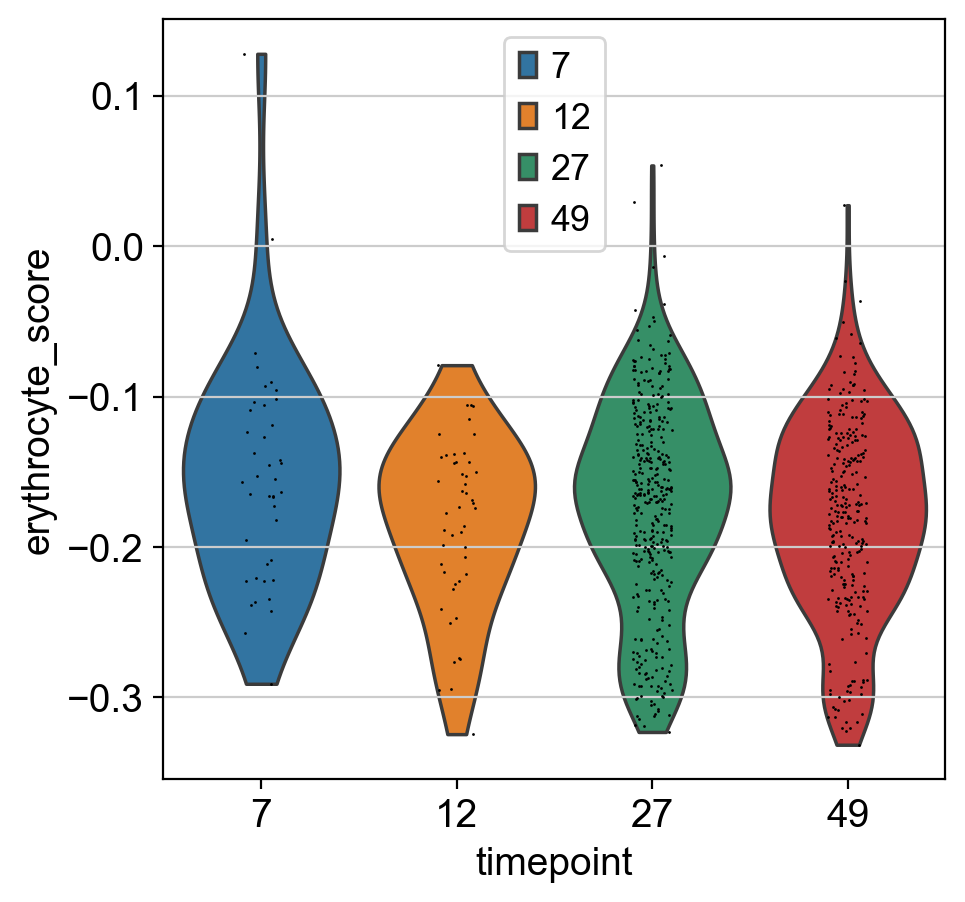

In [117]:
sc.tl.score_genes(HSC_ad, ery_genes, score_name='erythrocyte_score')
sc.pl.violin(HSC_ad, keys='erythrocyte_score', groupby='timepoint')

In [ ]:
'regulation of hemopoiesis'
'positive regulation of T cell differentiation'
'regulation of cell development'
'positive regulation of hemopoiesis'
'positive regulation of lymphocyte differentiation'

In [99]:
# enrich_HSC_result = sc.queries.enrich(sig_DEG_HSC_dict, org='mmusculus')
print(enrich_HSC_result.query("`query` == 'up' & `source` == 'GO:BP'").name.values)

['immune system process' 'cell activation'
 'regulation of immune system process' 'leukocyte activation'
 'lymphocyte activation' 'regulation of cell activation'
 'positive regulation of immune system process'
 'response to external stimulus' 'response to biotic stimulus'
 'regulation of leukocyte activation' 'response to stimulus'
 'regulation of multicellular organismal process'
 'response to other organism' 'response to external biotic stimulus'
 'hemopoiesis' 'mononuclear cell differentiation'
 'biological process involved in interspecies interaction between organisms'
 'leukocyte differentiation' 'regulation of lymphocyte activation'
 'T cell activation' 'cell-cell adhesion'
 'regulation of T cell activation' 'lymphocyte differentiation'
 'regulation of cell-cell adhesion' 'leukocyte cell-cell adhesion'
 'negative regulation of multicellular organismal process'
 'regulation of hemopoiesis' 'regulation of leukocyte cell-cell adhesion'
 'regulation of cell adhesion' 'positive regula

In [101]:
# enrich_result = sc.queries.enrich(sig_DEG_dict, org='mmusculus')
enrich_HSC_result.query("`query` == 'down' & `source` == 'GO:BP' ")

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
36,GO:BP,GO:0035456,response to interferon-beta,0.000022,True,"""Any process that results in a change in state...",58,69,6,25907,0.086957,0.103448,down,[GO:0034097]
46,GO:BP,GO:0048519,negative regulation of biological process,0.000108,True,"""Any process that stops, prevents, or reduces ...",5759,69,36,25907,0.521739,0.006251,down,"[GO:0008150, GO:0050789]"
58,GO:BP,GO:0051241,negative regulation of multicellular organisma...,0.000626,True,"""Any process that stops, prevents, or reduces ...",1157,69,15,25907,0.217391,0.012965,down,"[GO:0032501, GO:0048519, GO:0051239]"
62,GO:BP,GO:0042127,regulation of cell population proliferation,0.000907,True,"""Any process that modulates the frequency, rat...",1736,69,18,25907,0.260870,0.010369,down,"[GO:0008283, GO:0050794]"
78,GO:BP,GO:0050896,response to stimulus,0.001623,True,"""Any process that results in a change in state...",10427,69,48,25907,0.695652,0.004603,down,[GO:0008150]
91,GO:BP,GO:0051239,regulation of multicellular organismal process,0.005112,True,"""Any process that modulates the frequency, rat...",3080,69,23,25907,0.333333,0.007468,down,"[GO:0032501, GO:0050789]"
110,GO:BP,GO:0030154,cell differentiation,0.010722,True,"""The cellular developmental process in which a...",4795,69,29,25907,0.420290,0.006048,down,[GO:0048869]
111,GO:BP,GO:0048869,cellular developmental process,0.010768,True,"""A biological process whose specific outcome i...",4796,69,29,25907,0.420290,0.006047,down,"[GO:0009987, GO:0032502]"
120,GO:BP,GO:0008283,cell population proliferation,0.014060,True,"""The multiplication or reproduction of cells, ...",2103,69,18,25907,0.260870,0.008559,down,[GO:0009987]
126,GO:BP,GO:0009605,response to external stimulus,0.017672,True,"""Any process that results in a change in state...",2589,69,20,25907,0.289855,0.007725,down,[GO:0050896]


In [71]:
degs = []
for gs in [transcription_factors ,regulators_cofactors ,
           signaling ,chromatin_epigenetic,
           other_regulators,
           novel_factors]:
    degs.append(deg_HSC_ttest.query("`names` in @gs"))

deg_ery_diff = pd.concat(degs)

In [ ]:
mmusculus

In [72]:
deg_ery_diff

,names,scores,logfoldchanges,pvals,pvals_adj
965,Spi1,1.858399,0.365551,6.477903e-02,0.757594
1288,Klf1,1.667641,1.544100,9.635531e-02,0.844882
4329,Gata1,0.715099,0.403393,4.753130e-01,1.000000
4508,Gata2,0.650098,0.112546,5.165428e-01,1.000000
19831,Erg,-1.271928,-0.371558,2.055766e-01,0.984114
20098,Lmo2,-1.366475,-0.127457,1.738421e-01,0.981201
20270,Fli1,-1.419393,-0.277384,1.578049e-01,0.975584
20838,Tal1,-1.690428,-0.336733,9.279222e-02,0.837144
29,Sox6,5.075695,1.758990,6.574967e-07,0.000292
133,Myb,3.411210,0.520299,8.210490e-04,0.075108


In [64]:
deg_HSC_wilco.query("`names` in @ery_genes")

,names,scores,logfoldchanges,pvals,pvals_adj
7751,Id3,0.000000,0.000000,1.000000,1.0
9589,Hoxa13,0.000000,0.000000,1.000000,1.0
10036,Ebf1,0.000000,0.000000,1.000000,1.0
10761,Foxc1,0.000000,0.000000,1.000000,1.0
10950,Gcm2,0.000000,0.000000,1.000000,1.0
11901,Ppara,0.000000,0.000000,1.000000,1.0
12570,Hoxc9,0.000000,0.000000,1.000000,1.0
14435,Dppa2,-0.109745,-2.357436,0.912612,1.0
15465,Nfil3,-0.173430,-0.444458,0.862313,1.0
21402,Mef2c,-1.796853,-0.284296,0.072359,1.0
